<a href="https://colab.research.google.com/github/dev-anju/ParkZen/blob/main/parkZen_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00


In [2]:
!unzip -q /content/dataset.zip -d /content/

In [3]:
!find /content -type d -name "train"

/content/train


In [4]:
!find /content -name "data.yaml"

/content/data.yaml


In [5]:
import os

base_path = "/content"

for folder in ["train", "valid", "test"]:
    print(f"\n{folder.upper()}")
    print("Images:", len(os.listdir(f"{base_path}/{folder}/images")))
    print("Labels:", len(os.listdir(f"{base_path}/{folder}/labels")))


TRAIN
Images: 8691
Labels: 8691

VALID
Images: 2483
Labels: 2483

TEST
Images: 1242
Labels: 1242


In [6]:
from PIL import Image
import os

base_path = "/content"

bad_images = []

for folder in ["train", "valid", "test"]:
    img_dir = os.path.join(base_path, folder, "images")

    for img in os.listdir(img_dir):
        try:
            Image.open(os.path.join(img_dir, img)).verify()
        except:
            bad_images.append(os.path.join(img_dir, img))

print("Corrupted images:", len(bad_images))

if bad_images:
    for img in bad_images[:10]:
        print(img)

Corrupted images: 0


In [7]:
import os

base_path = "/content"

empty_labels = []

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join(base_path, folder, "labels")
    for label in os.listdir(label_dir):
        path = os.path.join(label_dir, label)

        if os.path.getsize(path) == 0:
            empty_labels.append(path)

print("Empty label files:", len(empty_labels))

Empty label files: 274


In [8]:
from collections import Counter
import os

counter = Counter()

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join("/content", folder, "labels")

    for file in os.listdir(label_dir):
        with open(os.path.join(label_dir, file), "r") as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    counter[cls] += 1

print(counter)

Counter({0: 376121, 1: 335735})


Total empty label images: 274
/content/train/images/2012-12-28_12_15_08_jpg.rf.84f7acfc868f4146e50fc4122d6dc132.jpg


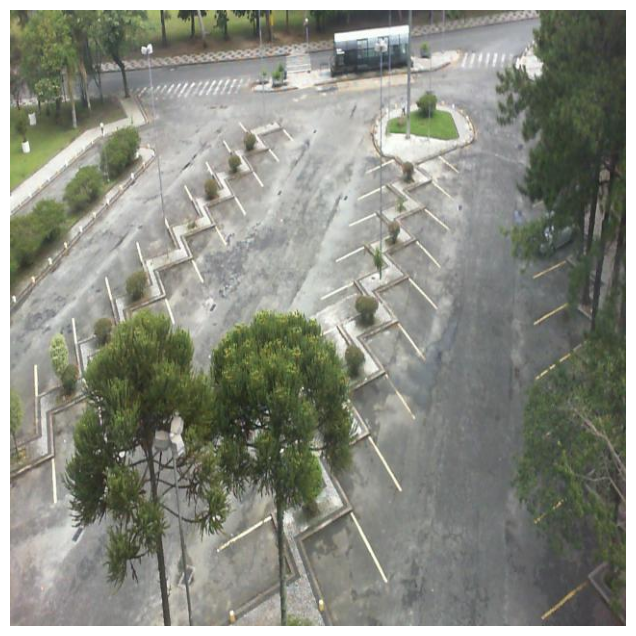

In [9]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

base_path = "/content"

empty = []

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join(base_path, folder, "labels")

    for label in os.listdir(label_dir):
        path = os.path.join(label_dir, label)
        if os.path.getsize(path) == 0:
            image_name = os.path.splitext(label)[0] + ".jpg"
            image_path = os.path.join(base_path, folder, "images", image_name)

            if os.path.exists(image_path):
                empty.append(image_path)

print("Total empty label images:", len(empty))

img = random.choice(empty)
print(img)

plt.figure(figsize=(8,8))
plt.imshow(Image.open(img))
plt.axis("off")
plt.show()

In [10]:
import os

image = "/content/train/images/2012-12-28_17_35_13_jpg.rf.6e06e01393ab5bf93e12cd8701ec5919.jpg"

label = image.replace("/images/", "/labels/").replace(".jpg", ".txt")

print("Label exists:", os.path.exists(label))

if os.path.exists(label):
    print("Label file size:", os.path.getsize(label))
    with open(label, "r") as f:
        print("Contents:")
        print(repr(f.read()))

Label exists: True
Label file size: 0
Contents:
''


In [11]:
from collections import Counter
import os

counter = Counter()

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join("/content", folder, "labels")

    for file in os.listdir(label_dir):
        with open(os.path.join(label_dir, file), "r") as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    counter[cls] += 1

print(counter)

Counter({0: 376121, 1: 335735})


In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=1,
    imgsz=640,
    batch=16,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchs

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c78bc1d73b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [13]:
import os
import random

label_folder = "/content/train/labels"

non_empty = []

for file in os.listdir(label_folder):
    path = os.path.join(label_folder, file)
    if os.path.getsize(path) > 0:
        non_empty.append(path)

print("Non-empty labels:", len(non_empty))

sample = random.choice(non_empty)

print("\nSample label file:")
print(sample)

with open(sample, "r") as f:
    print(f.read())

Non-empty labels: 8502

Sample label file:
/content/train/labels/2012-12-13_15_10_11_jpg.rf.e43757129aaa37e9bf6c35ea39b49752.txt
1 0.565625 0.865625 0.12578125 0.20703125
1 0.60546875 0.7203125 0.115625 0.1875
1 0.63515625 0.6234375 0.103125 0.1390625
1 0.653125 0.52265625 0.10078125 0.1484375
1 0.675 0.4515625 0.084375 0.11953125
1 0.69140625 0.375 0.0828125 0.10859375
1 0.70625 0.31875 0.08203125 0.0984375
1 0.7234375 0.271875 0.08125 0.08359375
1 0.734375 0.2265625 0.06640625 0.071875
1 0.43671875 0.86640625 0.1390625 0.16953125
1 0.5765625 0.43671875 0.09296875 0.09296875
1 0.60078125 0.37578125 0.090625 0.07890625
1 0.6203125 0.3140625 0.09140625 0.078125
1 0.6359375 0.26484375 0.084375 0.0625
1 0.6578125 0.22265625 0.06796875 0.0515625
1 0.3125 0.40078125 0.06015625 0.10703125
1 0.34921875 0.3421875 0.0609375 0.09296875
1 0.3875 0.2953125 0.059375 0.09296875
1 0.415625 0.24609375 0.0578125 0.075
1 0.44375 0.20546875 0.059375 0.078125
1 0.46796875 0.17265625 0.05625 0.07109375
1 0

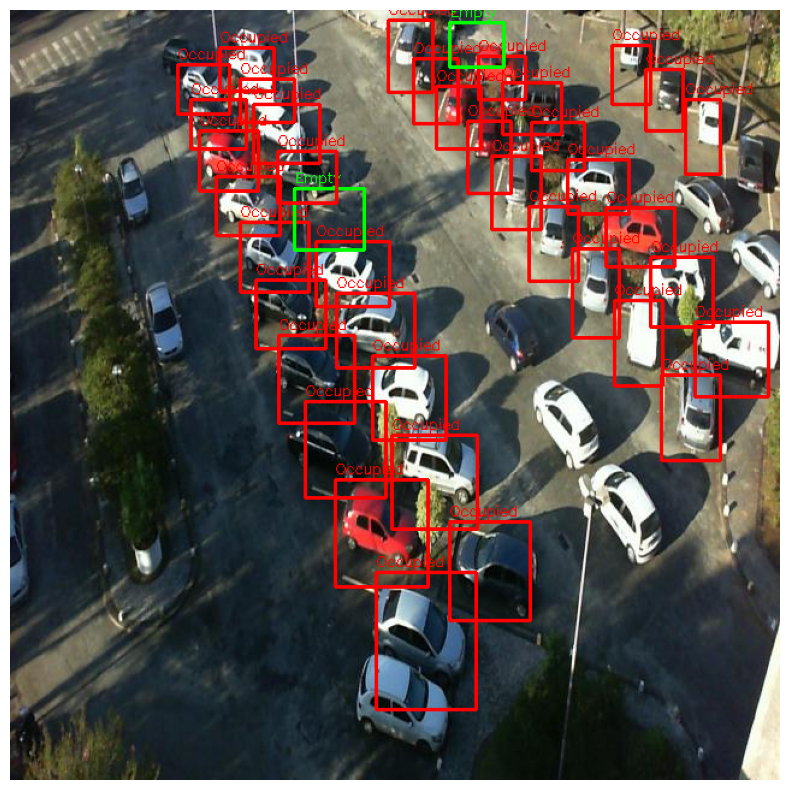

In [14]:
import cv2
import random
import os
import matplotlib.pyplot as plt

base = "/content"

# Random image
img_name = random.choice(os.listdir(f"{base}/train/images"))

img_path = os.path.join(base, "train/images", img_name)
label_path = os.path.join(base, "train/labels",
                          os.path.splitext(img_name)[0] + ".txt")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

if os.path.exists(label_path):
    with open(label_path) as f:
        for line in f:
            if line.strip():

                cls, xc, yc, bw, bh = map(float, line.split())

                xc *= w
                yc *= h
                bw *= w
                bh *= h

                x1 = int(xc - bw/2)
                y1 = int(yc - bh/2)
                x2 = int(xc + bw/2)
                y2 = int(yc + bh/2)

                color = (0,255,0) if int(cls)==0 else (255,0,0)

                cv2.rectangle(img,(x1,y1),(x2,y2),color,2)

                label = "Empty" if int(cls)==0 else "Occupied"

                cv2.putText(img,label,(x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.4,color,1)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
import os
import cv2
from collections import Counter

image_folder = "/content/train/images"

sizes = []

for img in os.listdir(image_folder):
    path = os.path.join(image_folder, img)
    image = cv2.imread(path)

    if image is not None:
        h, w = image.shape[:2]
        sizes.append((w, h))

counter = Counter(sizes)

print("Different image sizes found:")
for size, count in counter.items():
    print(size, ":", count)

Different image sizes found:
(640, 640) : 8691


In [16]:
import os
import hashlib

folder = "/content/train/images"

hashes = {}
duplicates = []

for filename in os.listdir(folder):
    filepath = os.path.join(folder, filename)

    with open(filepath, "rb") as f:
        filehash = hashlib.md5(f.read()).hexdigest()

    if filehash in hashes:
        duplicates.append((filename, hashes[filehash]))
    else:
        hashes[filehash] = filename

print("Duplicate Images:", len(duplicates))

Duplicate Images: 0


In [17]:
import os
import cv2

folder = "/content/train/images"

blur_images = []

for img in os.listdir(folder):

    path = os.path.join(folder, img)

    image = cv2.imread(path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if score < 100:
        blur_images.append((img, score))

print("Blurry Images:", len(blur_images))

Blurry Images: 38


In [18]:
import os
import cv2
import numpy as np

folder="/content/train/images"

dark=0
bright=0
normal=0

for img in os.listdir(folder):

    image=cv2.imread(os.path.join(folder,img))

    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

    mean=np.mean(gray)

    if mean<50:
        dark+=1
    elif mean>200:
        bright+=1
    else:
        normal+=1

print("Dark Images :",dark)
print("Bright Images :",bright)
print("Normal Images :",normal)

Dark Images : 0
Bright Images : 84
Normal Images : 8607


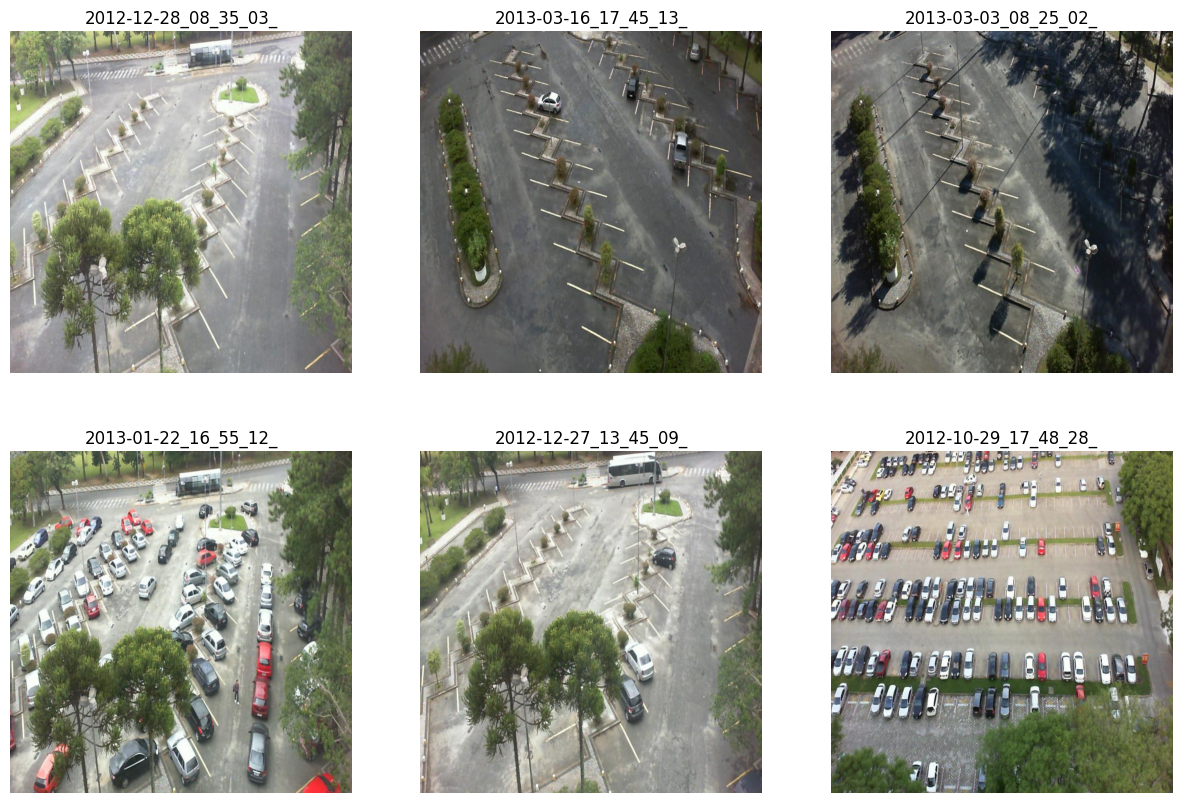

In [19]:
import os
import cv2
import random
import matplotlib.pyplot as plt

folder="/content/train/images"

samples=random.sample(os.listdir(folder),6)

plt.figure(figsize=(15,10))

for i,img in enumerate(samples):

    image=cv2.imread(os.path.join(folder,img))
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(img[:20])
    plt.axis("off")

plt.show()

In [20]:
import os
import shutil

folder = "/content/train/images"
label_folder = "/content/train/labels"

os.makedirs("/content/removed_blurry/images", exist_ok=True)
os.makedirs("/content/removed_blurry/labels", exist_ok=True)

for img, score in blur_images:
    shutil.move(os.path.join(folder, img),
                os.path.join("/content/removed_blurry/images", img))

    label = img.replace(".jpg", ".txt").replace(".png", ".txt").replace(".jpeg", ".txt")
    if os.path.exists(os.path.join(label_folder, label)):
        shutil.move(os.path.join(label_folder, label),
                    os.path.join("/content/removed_blurry/labels", label))

print("Moved", len(blur_images), "blurry images.")

Moved 38 blurry images.


In [21]:
import os

label_dirs = [
    "/content/train/labels",
    "/content/valid/labels",
    "/content/test/labels"
]

invalid = 0

for folder in label_dirs:
    for file in os.listdir(folder):
        if not file.endswith(".txt"):
            continue

        with open(os.path.join(folder, file)) as f:
            for line in f:
                if line.strip() == "":
                    continue

                cls, x, y, w, h = map(float, line.split())

                if not (0 <= x <= 1 and
                        0 <= y <= 1 and
                        0 < w <= 1 and
                        0 < h <= 1):
                    invalid += 1
                    print("Invalid:", file, line.strip())

print("Total invalid boxes:", invalid)

Total invalid boxes: 0


In [22]:
import os

for folder in ["train", "valid", "test"]:
    print(f"\n{folder.upper()}")
    print("Images:", len(os.listdir(f"/content/{folder}/images")))
    print("Labels:", len(os.listdir(f"/content/{folder}/labels")))


TRAIN
Images: 8653
Labels: 8653

VALID
Images: 2483
Labels: 2483

TEST
Images: 1242
Labels: 1242


In [23]:
!cat /content/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['space-empty', 'space-occupied']

roboflow:
  workspace: brad-dwyer
  project: pklot-1tros
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/brad-dwyer/pklot-1tros/dataset/2

In [24]:
%%writefile /content/data.yaml

path: /content

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied

Overwriting /content/data.yaml


In [25]:
!cat /content/data.yaml


path: /content

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied


In [26]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [ ]:
!cp -r /content/runs /content/drive/MyDrive/ParkingProject/

cp: cannot stat '/content/runs': No such file or directory


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import os

print(os.listdir("/content"))

['.config', 'train', 'README.dataset.txt', 'runs', 'valid', 'test', 'README.roboflow.txt', 'removed_blurry', 'yolov8n.pt', 'data.yaml', 'yolo26n.pt', 'drive', 'dataset.zip', 'sample_data']


In [31]:
import os

destination = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"
os.makedirs(destination, exist_ok=True)

In [32]:
import shutil

# Copy folders
shutil.copytree("/content/train", destination + "/train", dirs_exist_ok=True)
shutil.copytree("/content/valid", destination + "/valid", dirs_exist_ok=True)
shutil.copytree("/content/test", destination + "/test", dirs_exist_ok=True)

# Copy files
shutil.copy("/content/data.yaml", destination + "/data.yaml")
shutil.copy("/content/README.dataset.txt", destination + "/README.dataset.txt")
shutil.copy("/content/README.roboflow.txt", destination + "/README.roboflow.txt")

print("✅ Cleaned dataset saved to Google Drive!")

✅ Cleaned dataset saved to Google Drive!


In [33]:
!du -sh /content/train /content/valid /content/test

656M	/content/train
189M	/content/valid
93M	/content/test


In [34]:
import os

base = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

for root, dirs, files in os.walk(base):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*40)

/content/drive/MyDrive/Parking_Project/Cleaned_Dataset
Folders: ['train', 'valid', 'test']
Files: 3
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train
Folders: ['images', 'labels']
Files: 1
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/images
Folders: []
Files: 8653
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/labels
Folders: []
Files: 8653
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid
Folders: ['images', 'labels']
Files: 1
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/images
Folders: []
Files: 2483
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/labels
Folders: []
Files: 2483
----------------------------------------
/content/drive/MyDrive/Parking_Project/Cleane

In [35]:
with open("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml", "r") as f:
    print(f.read())


path: /content

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied



In [36]:
yaml_content = """path: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied
"""

with open("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml updated successfully!")

✅ data.yaml updated successfully!


In [37]:
with open("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml", "r") as f:
    print(f.read())

path: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied



In [38]:
import os

print("Train Images :", len(os.listdir("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/images")))
print("Train Labels :", len(os.listdir("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/labels")))

print("Valid Images :", len(os.listdir("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/images")))
print("Valid Labels :", len(os.listdir("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/labels")))

print("Test Images  :", len(os.listdir("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images")))
print("Test Labels  :", len(os.listdir("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels")))

Train Images : 8653
Train Labels : 8653
Valid Images : 2483
Valid Labels : 2483
Test Images  : 1242
Test Labels  : 1242


In [ ]:
import shutil

shutil.make_archive(
    "/content/Cleaned_Dataset",
    "zip",
    "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"
)

print("ZIP Created!")